In [2]:
!pip install wget

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9686 sha256=4b6be42a8e654c6088860bf258033b0090d3968ca9f8cec980389545a3819267
  Stored in directory: /Users/aditya/Library/Caches/pip/wheels/8b/f1/7f/5c94f0a7a505ca1c81cd1d9208ae2064675d97582078e6c769
Successfully built wget


In [6]:
!curl https://storage.googleapis.com/learning-datasets/irish-lyrics-eof.txt \
    -o /tmp/irish-lyrics-eof.txt

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 68970  100 68970    0     0  84345      0 --:--:-- --:--:-- --:--:-- 84418


In [ ]:
data = open('/tmp/irish-lyrics-eof.txt').read()
corpus = data.lower().split("\n")
print(corpus)

In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [10]:
vectorizer = tf.keras.layers.TextVectorization()
vectorizer.adapt(corpus)

In [11]:
vocabulary = vectorizer.get_vocabulary()
vocab_size = len(vocabulary)
print(f'{vocabulary}')
print(f'{vocab_size}')

['', '[UNK]', 'the', 'and', 'i', 'to', 'a', 'of', 'my', 'in', 'me', 'for', 'you', 'all', 'was', 'she', 'that', 'on', 'with', 'her', 'but', 'as', 'when', 'love', 'is', 'your', 'it', 'will', 'from', 'by', 'they', 'be', 'are', 'so', 'old', 'he', 'oh', 'no', 'ill', 'at', 'one', 'his', 'were', 'there', 'heart', 'down', 'where', 'we', 'now', 'young', 'never', 'go', 'then', 'not', 'did', 'come', 'said', 'away', 'them', 'their', 'sweet', 'green', 'take', 'if', 'our', 'like', 'out', 'night', 'town', 'this', 'have', 'fair', 'day', 'can', 'true', 'thou', 'theres', 'see', 'or', 'more', 'its', 'had', 'dear', 'would', 'up', 'over', 'o', 'ive', 'hear', 'well', 'through', 'home', 'again', 'oer', 'land', 'im', 'ye', 'still', 'sea', 'long', 'left', 'good', 'father', 'wild', 'rose', 'morning', 'could', 'who', 'eyes', 'while', 'took', 'little', 'him', 'first', 'bow', 'back', 'an', 'some', 'shall', 'say', 'mary', 'man', 'let', 'know', 'high', 'gone', 'get', 'ever', 'came', 'till', 'rosin', 'put', 'own', 'm

In [13]:
input_sequences = []

for line in corpus:
    sequence = vectorizer(line).numpy()
    for i in range(1, len(sequence)):
        n_gram_sequence = sequence[:i+1]
        input_sequences.append(n_gram_sequence)
max_len_sequence = max([len(x) for x in input_sequences])
input_sequences = np.array(tf.keras.utils.pad_sequences(input_sequences, max_len_sequence, padding='pre'))
xs, labels = input_sequences[:,:-1], input_sequences[:,-1]
ys = tf.keras.utils.to_categorical(labels, num_classes=vocab_size)

In [14]:
# Get sample sentence
sentence = corpus[0].split()
print(f'sample sentence: {sentence}')

# Initialize token list
token_list = []

# Look up the indices of each word and append to the list
for word in sentence:
  token_list.append(vocabulary.index(word))

# Print the token list
print(token_list)

sample sentence: ['come', 'all', 'ye', 'maidens', 'young', 'and', 'fair']
[55, 13, 96, 1886, 49, 3, 71]


In [15]:
def sequence_to_text(sequence, vocabulary):
  '''utility to convert integer sequence back to text'''

  # Loop through the integer sequence and look up the word from the vocabulary
  words = [vocabulary[index] for index in sequence]

  # Combine the words into one sentence
  text = tf.strings.reduce_join(words, separator=' ').numpy().decode()

  return text

In [16]:
# Pick element
elem_number = 5

# Print token list and phrase
print(f'token list: {xs[elem_number]}')
print(f'decoded to text: {sequence_to_text(xs[elem_number], vocabulary)}')

# Print label
print(f'one-hot label: {ys[elem_number]}')
print(f'index of label: {np.argmax(ys[elem_number])}')

token list: [   0    0    0    0    0    0    0    0    0   55   13   96 1886   49
    3]
decoded to text:          come all ye maidens young and
one-hot label: [0. 0. 0. ... 0. 0. 0.]
index of label: 71


In [17]:
PREFETCH_BUFFER_SIZE = tf.data.AUTOTUNE
BATCH_SIZE = 32

dataset = tf.data.Dataset.from_tensor_slices((xs, ys))
dataset = dataset.cache().prefetch(PREFETCH_BUFFER_SIZE).batch(BATCH_SIZE)

In [18]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(max_len_sequence-1,)),
    tf.keras.layers.Embedding(vocab_size, 100),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(vocab_size, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 15, 100)        │       270,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        34,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2704)           │       348,816 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 661,584 (2.52 MB)

 Trainable params: 661,584 (2.52 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(xs, ys, epochs=20)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0639 - loss: 6.7117
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0662 - loss: 6.2863
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0749 - loss: 6.0965
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0796 - loss: 5.9404
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0830 - loss: 5.7903
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0918 - loss: 5.6435
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0985 - loss: 5.5216
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1061 - loss: 5.4041
Epoch 9/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1113 - loss: 5.2883
Epoch 10/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1185 - loss: 5.1773
Epoch 11/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1218 - loss: 5.0748
Epoch 12/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

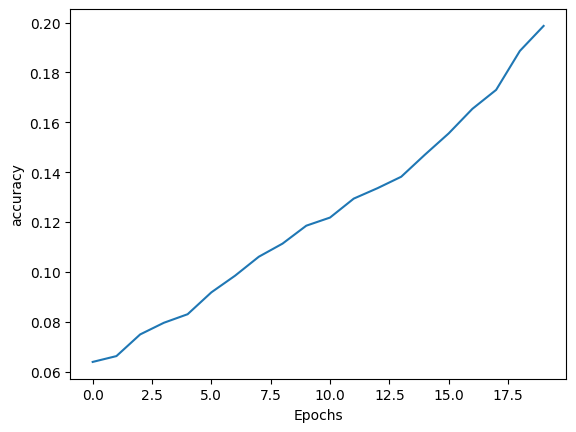

In [20]:
# Plot utility
def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.show()

# Visualize the accuracy
plot_graphs(history, 'accuracy')

In [21]:
seed_text = "aditya is the best"

next_words = 100

for _ in range(next_words):
    sequence = vectorizer(seed_text)
    sequence = tf.keras.utils.pad_sequences([sequence], max_len_sequence, padding='pre')
    probabilities = model.predict(sequence, verbose=0)
    predicted = np.argmax(probabilities, axis=-1)[0]
    if predicted != 0:
        output_word = vocabulary[predicted]
        seed_text += " " + output_word
print(seed_text)

aditya is the best too late are down and the bridge of toome today and fray in your in in fray laughing in fray for in your is they died in by in your are in side to fray in fray for by in your in in fray in fray for by in your they laughing laughing in your are in side to fulfill in fray for by in your they laughing in your are in by in your they laughing laughing in fray for side to heartfrom daylight in fray in fray for side to heartfrom daylight in side in by in by


In [22]:
seed_text = "aditya is not the best"

next_words = 100

for _ in range(next_words):
    sequence = vectorizer(seed_text)
    sequence = tf.keras.utils.pad_sequences([sequence], max_len_sequence, padding='pre')
    probabilities = model.predict(sequence, verbose=0)
    predicted = np.argmax(probabilities, axis=-1)[0]
    if predicted != 0:
        output_word = vocabulary[predicted]
        seed_text += " " + output_word
print(seed_text)

aditya is not the best are bright and she goes to go bragh side there in side to heartfrom daylight in fray laughing laughing in your they is they died in by in your they laughing laughing in fray in fray for side to heartfrom daylight in fray in fray for by in your they laughing laughing in your they died in fray for side to heartfrom daylight in fray for by in your they laughing laughing in fray in your they died in fray for side to heartfrom daylight in side in heartfrom daylight in side in by in by in your they is
